In [ ]:
#read in adata objects
import anndata as ad
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

### read in and combine annotated mz lists

In [56]:
# read in multiple annotated mz lists
mz_annotations_1 = pd.read_csv('annotations/alex_mz_list_curated_annotations.csv')
mz_annotations_2 = pd.read_csv('annotations/gus_mz_list_sal_glands_annotated.csv')
mz_annotations_3 = pd.read_csv('annotations/gus_mz_list_annotated.csv')
mz_annotations_4 = pd.read_csv('annotations/Annotated metabolites - most_interesting_mz.csv')
mz_annotations_5 = pd.read_csv('annotations/full_annotations.csv')
mz_annotations_6 = pd.read_csv('annotations/mz_list_v3_annotated.csv')
#mz_annotations_7 = pd.read_csv('annotations/subset_annotated_mets.csv')

In [57]:
# concatenate all annotated mz dataframes, adding a source column to identify their origin. based on different structures of the dataframes, two different concatenations were needed
dfs_labeled_1 = [
    mz_annotations_1.assign(source='alex_curated'),
    mz_annotations_5.assign(source='alex_all_organs'),
    mz_annotations_6.assign(source='v3_list')
]

mz_all_1 = pd.concat(dfs_labeled_1, ignore_index=True)

# concatenate all annotated mz dataframes, adding a source column to identify their origin
dfs_labeled_2 = [
    mz_annotations_2.assign(source='gus_salivary'),
    mz_annotations_3.assign(source='gus_all'),
    mz_annotations_4.assign(source='most_interesting')
    #mz_annotations_7.assign(source='subset_mets')
]

mz_all_2 = pd.concat(dfs_labeled_2, ignore_index=True)


In [58]:
#drop all duplicate m/z values, keeping the first occurrence
mz_all_1 = mz_all_1.drop_duplicates(subset=['m/z'])
mz_all_2 = mz_all_2.drop_duplicates(subset=['mz'])

In [60]:
#drop unnecessary columns
cols_to_drop = ['Color', 'Unnamed: 10', 'Column1', 'Column2']
mz_all_1 = mz_all_1.drop(columns=cols_to_drop, errors='ignore')
mz_all_2 = mz_all_2.drop(columns=cols_to_drop, errors='ignore')

In [61]:
#combine name and mz to have a single metabolite identifier column, since some files have names and some mz
mz_all_1['metabolite'] = mz_all_1['Name']
mz_all_2['metabolite'] = mz_all_2['mz']

In [62]:
#drop Name and mz columns now that we have a combined metabolite identifier
mz_all_1 = mz_all_1.drop(columns=['Name'], errors='ignore')
mz_all_2 = mz_all_2.drop(columns=['mz'], errors='ignore')

In [63]:
#put metabolite column first
cols = ['metabolite'] + [c for c in mz_all_1.columns if c != 'metabolite']
mz_all_1 = mz_all_1[cols]

cols = ['metabolite'] + [c for c in mz_all_2.columns if c != 'metabolite']
mz_all_2 = mz_all_2[cols]

In [64]:
# in m/z column of mz_annotations, find and remove 0 at the end of m/z values (e.g. mz243.06260 -> mz243.0626)
# add mz to the beginning of the m/z values
mz_all_1['m/z'] = 'mz' + mz_all_1['m/z'].astype(str)
# remove trailing 0
mz_all_1['m/z'] = mz_all_1['m/z'].str.replace('0$', '', regex=True)

In [65]:
# add m/z value to the end of each name when not already present by scanning for 'mz' in the string
def append_mz(name, mz):
    # If metabolite name is missing, create one from m/z
    if pd.isna(name):
        return f"{mz}"

    #name_str = str(name)

    # Append m/z only if not already present
    if 'mz' not in name.lower():
        return f"{name} ({mz})"

    return name

mz_all_1['Name'] = mz_all_1.apply(lambda row: append_mz(row['metabolite'], row['m/z']), axis=1)

### add annotations to adatas 

In [ ]:
#read in adata objects
adatas = ad.read_h5ad('background_removed/clean_all_organs_no_border_processed.h5ad')
sal_glands = ad.read_h5ad('background_removed/clean_salivary_glands_clustered.h5ad')
mz_all_1 = pd.read_csv('combined_mz_annotations_1.csv')

In [114]:
#store original name for reference
adatas.var['mz'] = adatas.var.index
sal_glands.var['mz'] = sal_glands.var.index

In [113]:
# reaplace var names with annotations where available
mapping = dict(zip(mz_all_1['m/z'], mz_all_1['Name']))
#all organs
adatas.var_names = [
    mapping.get(mz, str(mz))   # use annotation if exists, else keep m/z
    for mz in adatas.var_names
]
adatas.var_names_make_unique()
#sal glands
sal_glands.var_names = [
    mapping.get(mz, str(mz))   # use annotation if exists, else keep m/z
    for mz in sal_glands.var_names
]
sal_glands.var_names_make_unique()

In [116]:
#remove synonym annotations like [+1 syn.] from var names
#all organs
adatas.var_names = [
    re.sub(r'\[\+\d+\s*syn\.?\]', '', v).strip()
    for v in adatas.var_names
]
#sal glands
sal_glands.var_names = [
    re.sub(r'\[\+\d+\s*syn\.?\]', '', v).strip()
    for v in sal_glands.var_names
]

In [72]:
#function to remove trailing mz values eg. (mz123.456) from metabolite names. Only removes if something comes before it.
def remove_trailing_mz(name):
    if not isinstance(name, str):
        return name

    # Remove "(mz123.456)" only if something comes before it
    return re.sub(r'(.+?)\s*\(mz[0-9.]+\)$', r'\1', name).strip()


In [73]:
#remove trailing mz values from var names
#all organs
adatas.var_names = [remove_trailing_mz(v) for v in adatas.var_names]
#sal glands
sal_glands.var_names = [remove_trailing_mz(v) for v in sal_glands.var_names]

In [74]:
#remove training commas and spaces from the end of var names
#all organs
adatas.var_names = (
    adatas.var_names
    .astype(str)
    # remove trailing (mz...)
    .str.replace(r'(.+?)\s*\(mz[0-9.]+\)$', r'\1', regex=True)
    # remove trailing commas and spaces
    .str.replace(r'[,\s]+$', '', regex=True)
)
#sal glands
sal_glands.var_names = (
    sal_glands.var_names
    .astype(str)
    # remove trailing (mz...)
    .str.replace(r'(.+?)\s*\(mz[0-9.]+\)$', r'\1', regex=True)
    # remove trailing commas and spaces
    .str.replace(r'[,\s]+$', '', regex=True)
)

In [75]:
#where var names are still 'unknown123', add original mz value
# all organs
mask = adatas.var_names.str.match(r'^unknown\d+$', case=False)
adatas.var_names = adatas.var_names.where(
    ~mask,
    adatas.var['mz']
)
# sal glands
mask = sal_glands.var_names.str.match(r'^unknown\d+$', case=False)
sal_glands.var_names = sal_glands.var_names.where(
    ~mask,
    sal_glands.var['mz']
)

In [93]:
# make var names unique again
adatas.var_names_make_unique()
sal_glands.var_names_make_unique()

In [ ]:
#save all_organs to h5ad
adatas.write_h5ad('background_removed/all_organs_annotated_5_1_26.h5ad')
#save salivary glands to h5ad
sal_glands.write_h5ad('background_removed/salivary_glands_annotated_5_1_26.h5ad')

### plotting PCA loadings

#### all organs

In [122]:
# Extract PC1 loadings
pc1_loadings = adatas.varm['PCs'][:, 0]

# Create dataframe
df = pd.DataFrame({
    "Metabolite": adatas.var_names,
    "Loading": pc1_loadings
})

# Select top 10 by absolute contribution
df_top10 = (
    df
    .assign(abs_loading=np.abs(df["Loading"]))
    .sort_values("abs_loading", ascending=False)
    .head(10)
    .sort_values("Loading")  # for nicer plotting
)


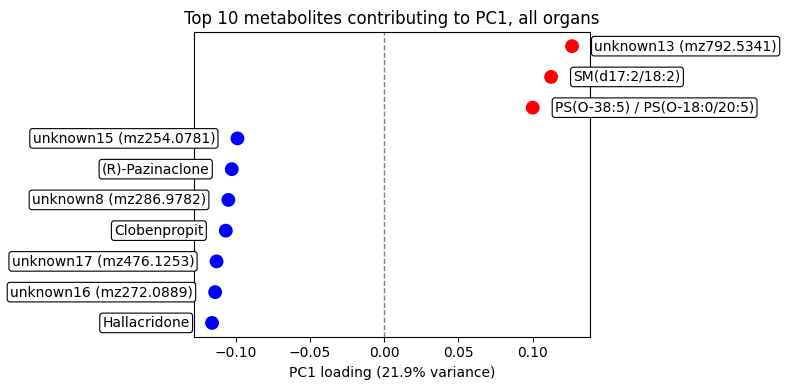

In [ ]:
# Vertical positions
y = np.arange(len(df_top10))

# Colors by sign
colors = df_top10["Loading"].apply(
    lambda x: "red" if x > 0 else "blue"
)

plt.figure(figsize=(8, 4))

# Plot points
plt.scatter(
    df_top10["Loading"],
    y,
    s=80,
    c=colors,
    zorder=3
)


# Zero line
plt.axvline(0, color="gray", linestyle="--", linewidth=1, zorder=1)

# Remove y-axis
plt.yticks([])
plt.ylabel("")

# Add label boxes
for yi, (name, val) in enumerate(zip(df_top10["Metabolite"], df_top10["Loading"])):
    offset = 0.015 * np.sign(val)  # push label away from zero

    plt.text(
        val + offset,
        yi,
        name,
        va="center",
        ha="left" if val > 0 else "right",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        ),
        zorder=4
    )
var_pc1 = adatas.uns["pca"]["variance_ratio"][0] * 100
plt.xlabel(f"PC1 loading ({var_pc1:.1f}% variance)")

#plt.xlabel("PC1 loading")
plt.title("Top 10 metabolites contributing to PC1, all organs")
plt.tight_layout()

# Define output prefix
out_prefix = "top10_PC1_metabolites_all_organs"

# Save vector formats
plt.savefig(f"plots/{out_prefix}.svg", format="svg", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/{out_prefix}.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
# Extract PC2 loadings
pc2_loadings = adatas.varm['PCs'][:, 1]

# Create dataframe
df_2 = pd.DataFrame({
    "Metabolite": adatas.var_names,
    "Loading": pc2_loadings
})

# Select top 10 by absolute contribution
df_top10_2 = (
    df_2
    .assign(abs_loading=np.abs(df_2["Loading"]))
    .sort_values("abs_loading", ascending=False)
    .head(10)
    .sort_values("Loading")  # for nicer plotting
)


/var/folders/ft/9cnhb36s19ld2jkvqs5qst1r0000gn/T/ipykernel_2964/1989192556.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


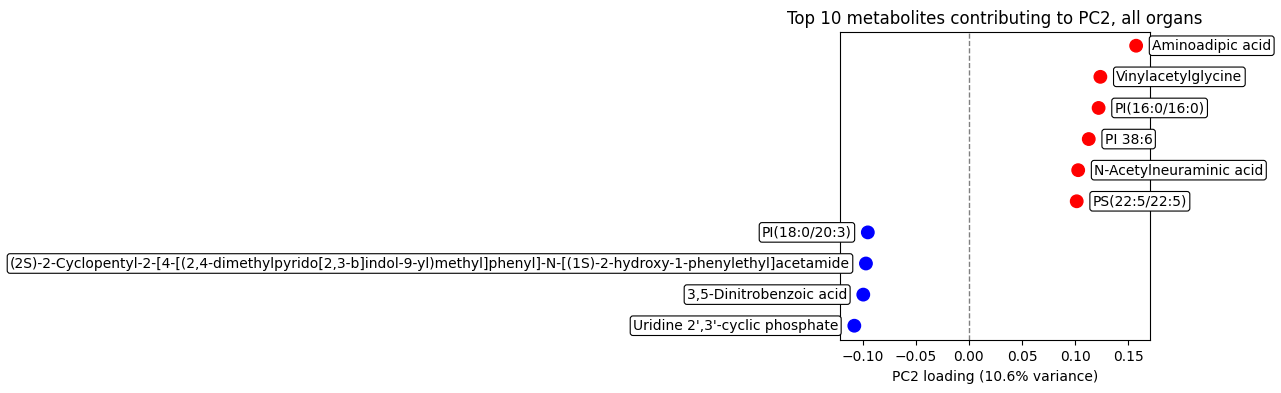

In [121]:
# Vertical positions
y = np.arange(len(df_top10_2))

# Colors by sign
colors = df_top10_2["Loading"].apply(
    lambda x: "red" if x > 0 else "blue"
)

plt.figure(figsize=(4, 4))

# Plot points
plt.scatter(
    df_top10_2["Loading"],
    y,
    s=80,
    c=colors,
    zorder=3
)


# Zero line
plt.axvline(0, color="gray", linestyle="--", linewidth=1, zorder=1)

# Remove y-axis
plt.yticks([])
plt.ylabel("")

# Add label boxes
for yi, (name, val) in enumerate(zip(df_top10_2["Metabolite"], df_top10_2["Loading"])):
    offset = 0.015 * np.sign(val)  # push label away from zero

    plt.text(
        val + offset,
        yi,
        name,
        va="center",
        ha="left" if val > 0 else "right",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        ),
        zorder=4
    )
var_pc2 = adatas.uns["pca"]["variance_ratio"][1] * 100
plt.xlabel(f"PC2 loading ({var_pc2:.1f}% variance)")

#plt.xlabel("PC1 loading")
plt.title("Top 10 metabolites contributing to PC2, all organs")
plt.tight_layout()

# Define output prefix
out_prefix = "top10_PC2_metabolites_all_organs"

# Save vector formats
plt.savefig(f"plots/{out_prefix}.svg", format="svg", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/{out_prefix}.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()


#### salivary glands

In [3]:
# Extract PC1 loadings
pc1_loadings_sal = sal_glands.varm['PCs'][:, 0]

# Create dataframe
df_sal = pd.DataFrame({
    "Metabolite": sal_glands.var_names,
    "Loading": pc1_loadings_sal
})

# Select top 10 by absolute contribution
df_top10_sal = (
    df_sal
    .assign(abs_loading=np.abs(df_sal["Loading"]))
    .sort_values("abs_loading", ascending=False)
    .head(10)
    .sort_values("Loading")  # for nicer plotting
)


/var/folders/ft/9cnhb36s19ld2jkvqs5qst1r0000gn/T/ipykernel_2964/3811311037.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


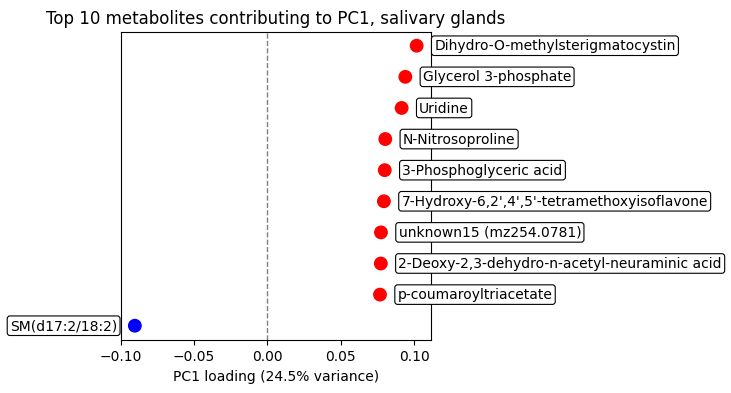

In [134]:
# Vertical positions
y = np.arange(len(df_top10_sal))

# Colors by sign
colors = df_top10_sal["Loading"].apply(
    lambda x: "red" if x > 0 else "blue"
)

plt.figure(figsize=(4, 4))

# Plot points
plt.scatter(
    df_top10_sal["Loading"],
    y,
    s=80,
    c=colors,
    zorder=3
)


# Zero line
plt.axvline(0, color="gray", linestyle="--", linewidth=1, zorder=1)

# Remove y-axis
plt.yticks([])
plt.ylabel("")

# Add label boxes
for yi, (name, val) in enumerate(zip(df_top10_sal["Metabolite"], df_top10_sal["Loading"])):
    offset = 0.012 * np.sign(val)  # push label away from zero

    plt.text(
        val + offset,
        yi,
        name,
        va="center",
        ha="left" if val > 0 else "right",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        ),
        zorder=4
    )
var_pc1 = sal_glands.uns["pca"]["variance_ratio"][0] * 100
plt.xlabel(f"PC1 loading ({var_pc1:.1f}% variance)")

#plt.xlabel("PC1 loading")
plt.title("Top 10 metabolites contributing to PC1, salivary glands")
plt.tight_layout()

# Define output prefix
out_prefix = "top10_PC1_metabolites_salivary_glands"

# Save vector formats
plt.savefig(f"plots/{out_prefix}.svg", format="svg", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/{out_prefix}.pdf", format="pdf", dpi=300, bbox_inches="tight")


plt.show()


In [ ]:
# Extract PC2 loadings
pc2_loadings_sal = sal_glands.varm['PCs'][:, 1]

# Create dataframe
df_sal_2 = pd.DataFrame({
    "Metabolite": sal_glands.var_names,
    "Loading": pc2_loadings_sal
})

# Select top 10 by absolute contribution
df_top10_sal_2 = (
    df_sal_2
    .assign(abs_loading=np.abs(df_sal_2["Loading"]))
    .sort_values("abs_loading", ascending=False)
    .head(10)
    .sort_values("Loading")  # for nicer plotting
)


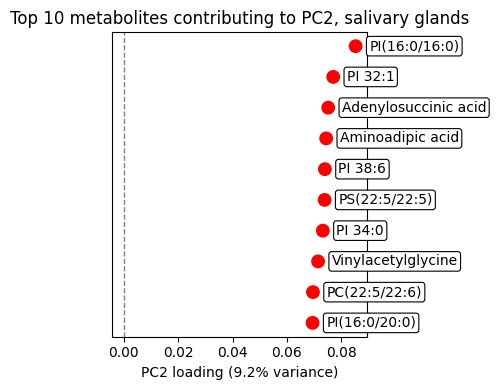

In [137]:
# Vertical positions
y = np.arange(len(df_top10_sal_2))

# Colors by sign
colors = df_top10_sal_2["Loading"].apply(
    lambda x: "red" if x > 0 else "blue"
)

plt.figure(figsize=(4, 4))

# Plot points
plt.scatter(
    df_top10_sal_2["Loading"],
    y,
    s=80,
    c=colors,
    zorder=3
)


# Zero line
plt.axvline(0, color="gray", linestyle="--", linewidth=1, zorder=1)

# Remove y-axis
plt.yticks([])
plt.ylabel("")

# Add label boxes
for yi, (name, val) in enumerate(zip(df_top10_sal_2["Metabolite"], df_top10_sal_2["Loading"])):
    offset = 0.005 * np.sign(val)  # push label away from zero

    plt.text(
        val + offset,
        yi,
        name,
        va="center",
        ha="left" if val > 0 else "right",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            linewidth=0.8
        ),
        zorder=4
    )
var_pc2 = sal_glands.uns["pca"]["variance_ratio"][1] * 100
plt.xlabel(f"PC2 loading ({var_pc2:.1f}% variance)")

#plt.xlabel("PC1 loading")
plt.title("Top 10 metabolites contributing to PC2, salivary glands")
plt.tight_layout()

# Define output prefix
out_prefix = "top10_PC2_metabolites_salivary_glands"

# Save vector formats
plt.savefig(f"plots/{out_prefix}.svg", format="svg", dpi=300, bbox_inches="tight")
plt.savefig(f"plots/{out_prefix}.pdf", format="pdf", dpi=300, bbox_inches="tight")


plt.show()


### create list of mz to annotate
#### leftovers that were not annotated previously but are present in the loading plots 

In [251]:
mz_to_annotate = []

#add mz values for top 10 PC1 metabolites in salivary glands into column mz and add column origin 
for metabolite in df_top10_sal['Metabolite']:
    mz_value = sal_glands.var.loc[sal_glands.var_names == metabolite, 'mz'].values
    if len(mz_value) > 0:
        mz_to_annotate.append({'mz': mz_value[0], 'origin': f'PC 1 defining MZ, salivary glands'})
    else:
        mz_to_annotate.append(None)

for metabolite in df_top10_sal_2['Metabolite']:
    mz_value = sal_glands.var.loc[sal_glands.var_names == metabolite, 'mz'].values
    if len(mz_value) > 0:
        mz_to_annotate.append({'mz': mz_value[0], 'origin': f'PC 2 defining MZ, salivary glands'})
    else:
        mz_to_annotate.append(None)

for metabolite in df_top10['Metabolite']:
    mz_value = adatas.var.loc[adatas.var_names == metabolite, 'mz'].values
    if len(mz_value) > 0:
        mz_to_annotate.append({'mz': mz_value[0], 'origin': f'PC 1 defining MZ, all organs'})
    else:
        mz_to_annotate.append(None)

for metabolite in df_top10_2['Metabolite']:
    mz_value = adatas.var.loc[adatas.var_names == metabolite, 'mz'].values
    if len(mz_value) > 0:
        mz_to_annotate.append({'mz': mz_value[0], 'origin': f'PC 2 defining MZ, all organs'})
    else:
        mz_to_annotate.append(None)

mz_to_annotate_df = pd.DataFrame(mz_to_annotate)

In [253]:
mask = mz_to_annotate_df['mz'].astype(str).str.match(r'^mz\d+(\.\d+)?$')
df_mz_only = mz_to_annotate_df.loc[mask]

In [255]:
#save to csv
df_mz_only.to_csv('margot_mz_to_annotate.csv', index=False)

### add mz values to signature metabolite list

In [4]:
mz_all_1 = pd.read_csv('annotations/combined_mz_annotations_1.csv')
sigmets = pd.read_csv('background_removed/signature_metabolites.csv')

In [7]:
#add column to sigmets with m/z values from mz_all_1 by matching mz column in sigmets to Name column in mz_all_1
sigmets = sigmets.merge(
    mz_all_1[['m/z', 'Name']],
    left_on='mz',
    right_on='Name',
    how='left'
).drop(columns=['Name'])  

In [ ]:
#where m/z is NaN, fill with mz value from mz column
sigmets['m/z'] = sigmets.apply(
    lambda row: row['mz'] if pd.isna(row['m/z']) else row['m/z'],
    axis=1
)

In [11]:
#save updated sigmets to csv
sigmets.to_csv('background_removed/signature_metabolites.csv', index=False)

### add top10 metabolites pc1 pc2 salivary glands to ms2 list


In [10]:
df_top10_sal_2, df_top10_sal

(               Metabolite   Loading  abs_loading
 904         PI(16:0/20:0)  0.069447     0.069447
 920         PC(22:5/22:6)  0.069597     0.069597
 69     Vinylacetylglycine  0.071470     0.071470
 877               PI 34:0  0.073222     0.073222
 908         PS(22:5/22:5)  0.073871     0.073871
 906               PI 38:6  0.073985     0.073985
 98       Aminoadipic acid  0.074453     0.074453
 534  Adenylosuccinic acid  0.075201     0.075201
 850               PI 32:1  0.077045     0.077045
 852         PI(16:0/16:0)  0.085279     0.085279,
                                        Metabolite   Loading  abs_loading
 766                                SM(d17:2/18:2) -0.090432     0.090432
 282                         p-coumaroyltriacetate  0.076806     0.076806
 284  2-Deoxy-2,3-dehydro-n-acetyl-neuraminic acid  0.077360     0.077360
 238                        unknown15 (mz254.0781)  0.077458     0.077458
 398   7-Hydroxy-6,2',4',5'-tetramethoxyisoflavone  0.079463     0.079463
 147 

In [28]:
# add df_top10_sal column Metabolite to column Metabolite of metabolite_combinations_expanded_df, with Column Origin saying 'PC2 defining'
metabolite_combinations_expanded_df = pd.read_csv('metabolite_combinations_by_organs_expanded.csv')

In [29]:
#add column to metabolite_combinations_expanded_df with metabolites from df_top10_sal with origin 'PC2 defining, salivary glands'
for metabolite in df_top10_sal['Metabolite']:
    metabolite_combinations_expanded_df = pd.concat([
        metabolite_combinations_expanded_df,
        pd.DataFrame({
            'Origin': ['PC1 defining, salivary glands'],
            'Metabolite': [metabolite]
        })
    ], ignore_index=True)

In [30]:
#add column to metabolite_combinations_expanded_df with metabolites from df_top10_sal_2 with origin 'PC2 defining, salivary glands'
for metabolite in df_top10_sal_2['Metabolite']:
    metabolite_combinations_expanded_df = pd.concat([
        metabolite_combinations_expanded_df,
        pd.DataFrame({
            'Origin': ['PC2 defining, salivary glands'],
            'Metabolite': [metabolite]
        })
    ], ignore_index=True)

In [33]:
# find doublets in metabolite_combinations_expanded_df based on Metabolite column
duplicates = metabolite_combinations_expanded_df[metabolite_combinations_expanded_df.duplicated(subset=['Metabolite'], keep=False)]

In [35]:
# where duplicates exist, keep only one occurence with combined Origin values
metabolite_combinations_expanded_df = (
    metabolite_combinations_expanded_df
    .groupby('Metabolite', as_index=False)
    .agg({'Origin': lambda x: ', '.join(sorted(set(x)))})
)

In [39]:
mz_all = pd.read_csv('annotations/combined_mz_annotations_1.csv')

In [ ]:
#add m/z column to metabolite_combinations_expanded_df by matching Metabolite column to Name column in mz_all
metabolite_combinations_expanded_df = metabolite_combinations_expanded_df.merge(
    mz_all[['m/z', 'Name']],
    left_on='Metabolite',
    right_on='Name',
    how='left'
).drop(columns=['Name'])

#where m/z is NaN, fill with Metabolite value
metabolite_combinations_expanded_df['m/z'] = metabolite_combinations_expanded_df.apply(
    lambda row: row['Metabolite'] if pd.isna(row['m/z']) else row['m/z'],
    axis=1
)

In [47]:
# add a column called priority with 'priority' if Origin contains 'PC1 defining' or 'PC2 defining', else 'non-priority'
metabolite_combinations_expanded_df['priority'] = metabolite_combinations_expanded_df['Origin'].apply(
    lambda x: 'priority' if 'PC1 defining' in x or 'PC2 defining' in x or 'top_RPG' in x or 'top_SLG' in x else 'non-priority')

In [50]:
metabolite_combinations_expanded_df.to_csv('metabolite_combinations_by_organs_expanded.csv', index=False)